In [2]:
import pandas as pd
import numpy as np


In [3]:

df = pd.read_csv('StudentPerformanceFactors.csv')
std_data = df[df['Exam_Score'] != 101]

In [4]:
std_data.reset_index(inplace = True)

In [5]:
std_data.drop(columns='index' , inplace= True)

C:\Users\risha\AppData\Local\Temp\ipykernel_18412\1207855288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  std_data.drop(columns='index' , inplace= True)


In [6]:
corr_matrix = std_data.corr(numeric_only=True)
corr_matrix['Exam_Score'].sort_values(ascending = False)

Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

plt.rcParams.update({
    "figure.figsize": (20, 10),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 1
})

<Axes: >

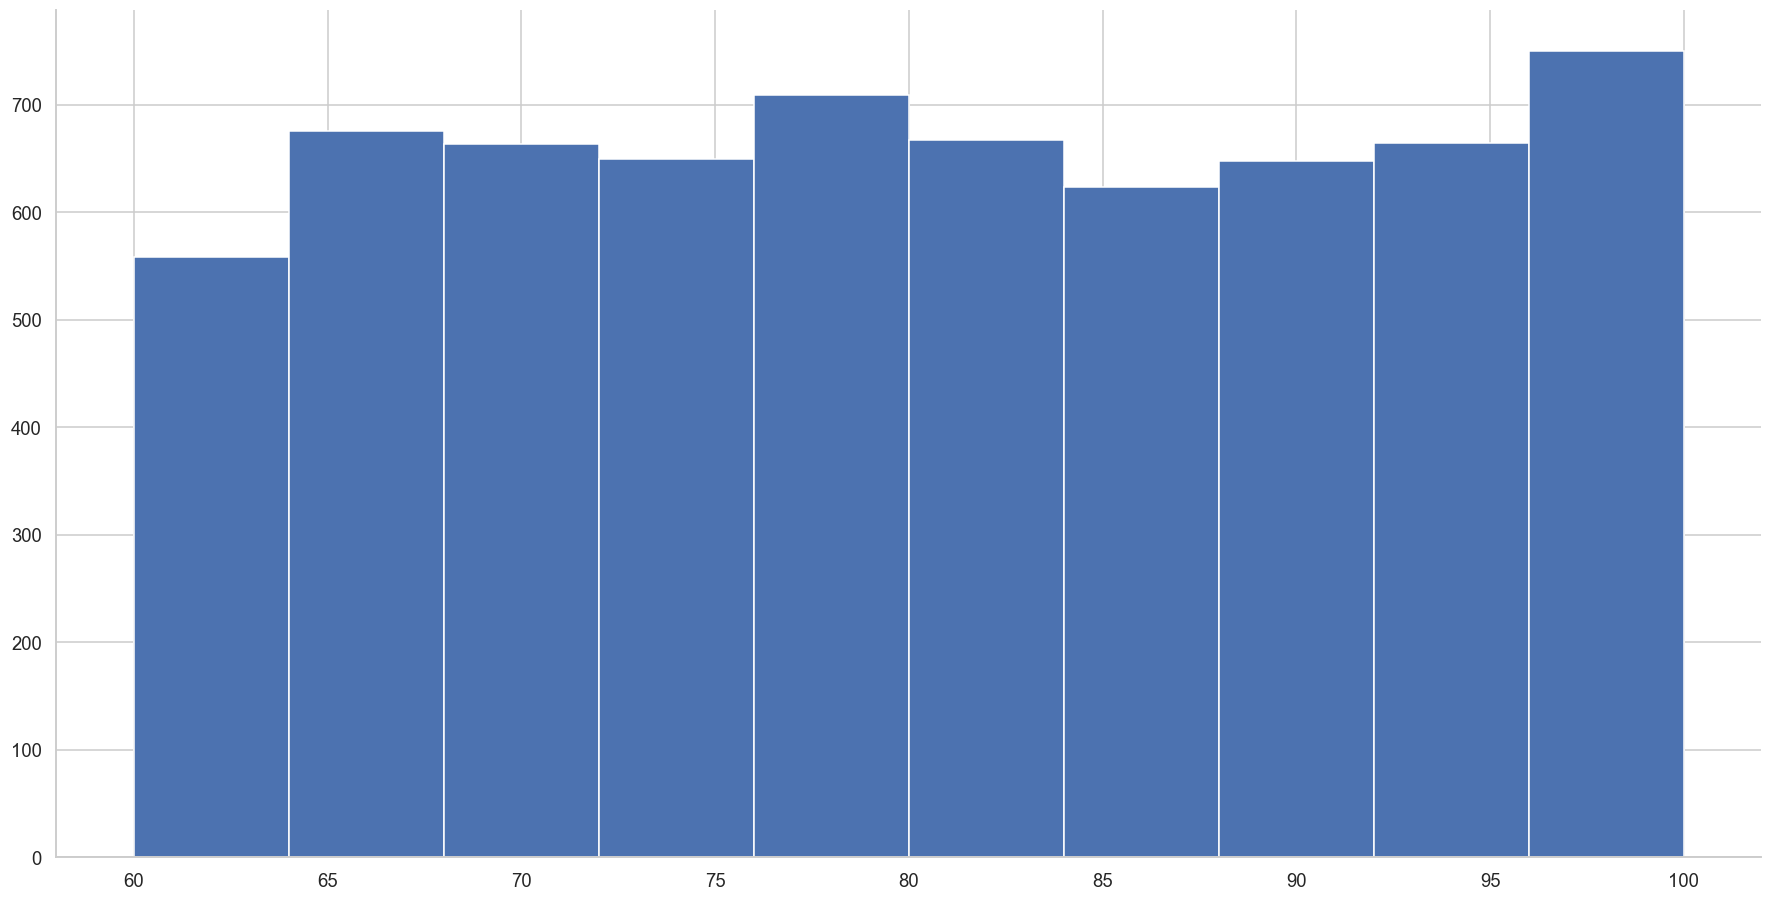

In [8]:
std_data['Attendance'].hist()

In [9]:
std_data['attendance_cat'] = pd.cut(std_data['Attendance'] ,
                            bins = [0,60,70,80,90,100],
                            labels=[1,2,3,4,5]
                            )
std_data['Study_hrs_cat'] = pd.cut(std_data['Hours_Studied'] ,
                            bins = [0,4,14,24,34,44],
                            labels=[1,2,3,4,5]
                            )

C:\Users\risha\AppData\Local\Temp\ipykernel_18412\1895837654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  std_data['attendance_cat'] = pd.cut(std_data['Attendance'] ,
C:\Users\risha\AppData\Local\Temp\ipykernel_18412\1895837654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  std_data['Study_hrs_cat'] = pd.cut(std_data['Hours_Studied'] ,


In [10]:
std_data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6606.000000,6606.000000,6606.000000,6606.000000,6606.000000,6606.000000,6606.000000
mean,19.974266,79.974720,7.029216,75.067817,1.493188,2.967605,67.230548
std,5.990424,11.546219,1.468177,14.399184,1.229907,1.031309,3.868502
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,100.000000


In [11]:
from sklearn.model_selection  import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits= 1 , test_size=0.2 )
stratified_col = pd.concat([std_data['attendance_cat'] , 
                            std_data['Study_hrs_cat']] , axis= 1)

for train_idx , test_idx in split.split(std_data  , stratified_col):
    strat_test = std_data.loc[test_idx]
    strat_train = std_data.loc[train_idx]



In [12]:
strat_train_set = strat_train.reset_index(drop={'columns' : 'index'})

In [13]:
strat_test_set = strat_test.reset_index(drop={'columns' : 'index'})

In [14]:
strat_train_set

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,attendance_cat,Study_hrs_cat
0,16,61,High,High,No,8,64,Medium,Yes,1,...,Public,Positive,3,No,High School,Far,Male,62,2,3
1,22,88,Medium,Low,Yes,7,70,Medium,Yes,3,...,Public,Positive,2,No,High School,Near,Female,69,4,3
2,28,78,High,Medium,Yes,7,86,Low,Yes,0,...,Public,Neutral,2,No,College,Moderate,Male,69,3,4
3,11,78,Medium,Low,Yes,7,98,Low,Yes,2,...,Public,Neutral,3,No,High School,Near,Female,64,3,2
4,30,84,High,Medium,No,8,51,Low,Yes,1,...,Public,Positive,4,Yes,Postgraduate,Far,Male,69,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5279,15,65,Medium,Medium,No,9,65,Medium,Yes,1,...,Public,Neutral,2,No,College,Near,Female,61,2,3
5280,20,83,Medium,Low,No,6,51,Low,Yes,2,...,Public,Neutral,4,No,High School,Moderate,Female,65,4,3
5281,20,80,Low,Low,Yes,7,59,High,Yes,2,...,Private,Neutral,3,No,High School,Moderate,Male,65,3,3
5282,20,83,High,Medium,No,7,89,Medium,Yes,3,...,Private,Negative,4,No,High School,Near,Female,69,4,3


In [15]:
X_train = strat_train_set.drop(columns='Exam_Score')
y_train = strat_train_set['Exam_Score']

In [16]:
cat_list = [ i for i in X_train.columns if std_data[i].dtype=='object' ]
num_list = [ i for i in X_train.columns if std_data[i].dtype!='object' ]

In [17]:
from scipy.stats import chi2_contingency
# table = pd.crosstab()

In [18]:
# chi2, p, dof, expected = chi2_contingency(table)

In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# for i in cat_list:
#     model = ols(f'Exam_Score ~ C({i})', data=strat_train_set).fit()



#     anova_table = sm.stats.anova_lm(model, typ=3)
#     if (anova_table['PR(>F)']<= 0.05).any():
#         print(i , 'no effect ')


#     else:
#         print(i , ' has effect')

# anova_table
    
# \

In [20]:

# for i in cat_list:
#     model = ols(f'Exam_Score ~ C({i})', data=strat_train_set).fit()



#     anova_table = sm.stats.anova_lm(model, typ=2)
#     if (anova_table['PR(>F)']<= 0.05).any():
#         print(i , 'no effect ')


#     else:
#         print(i , ' has effect')
#wrong

for i in cat_list:
    model = ols(f'Exam_Score ~ C({i})', data=strat_train_set).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    p_value = anova_table.loc[f'C({i})', 'PR(>F)']

    if p_value <= 0.05:
        print(i, 'has effect')
    else:
        print(i, 'no significant effect')




Parental_Involvement has effect
Access_to_Resources has effect
Extracurricular_Activities has effect
Motivation_Level has effect
Internet_Access has effect
Family_Income has effect
Teacher_Quality has effect
School_Type no significant effect
Peer_Influence has effect
Learning_Disabilities has effect
Parental_Education_Level has effect
Distance_from_Home has effect
Gender no significant effect


<Axes: xlabel='Attendance', ylabel='Exam_Score'>

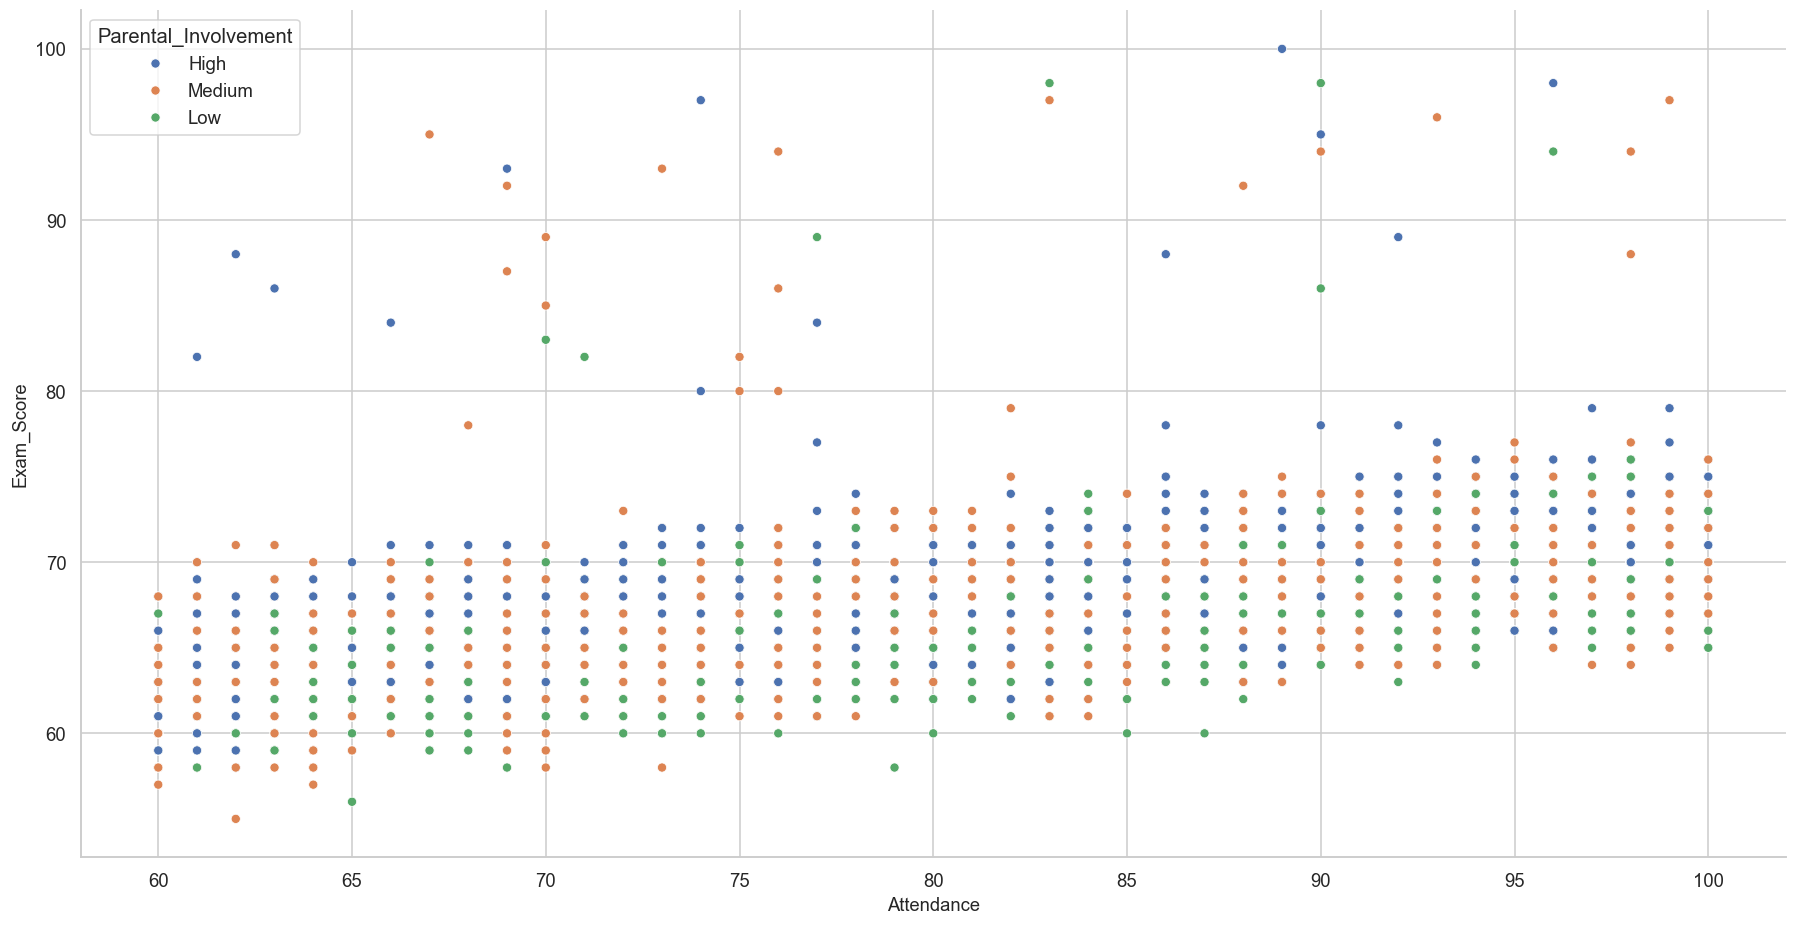

In [21]:
sns.scatterplot(data = X_train , x = 'Attendance'  ,y = y_train 
                , hue = 'Parental_Involvement')







In [22]:
std_data.loc[std_data['School_Type'] == "Private", 'Exam_Score'].mean()
std_data.loc[std_data['School_Type'] == "Public", 'Exam_Score'].mean()
std_data.loc[std_data['School_Type'] == "Public", 'Exam_Score'].mean()


np.float64(67.20556884924952)

In [23]:
strat_train_set.loc[strat_train_set['Parental_Involvement'] == "Low", 'Exam_Score'].median()
strat_train_set.loc[strat_train_set['Parental_Involvement'] == "Medium", 'Exam_Score'].median()

strat_train_set.loc[strat_train_set['Parental_Involvement'] == "High", 'Exam_Score'].median()



np.float64(68.0)

In [24]:
for  i in cat_list:
    for j in strat_train_set[i].unique():
        median = strat_train_set.loc[strat_train_set[i] == j, 'Exam_Score'].median()
        print(f'{i} : The median for category {j} is {median}')
    print('\n')       

Parental_Involvement : The median for category High is 68.0
Parental_Involvement : The median for category Medium is 67.0
Parental_Involvement : The median for category Low is 66.0


Access_to_Resources : The median for category High is 68.0
Access_to_Resources : The median for category Low is 66.0
Access_to_Resources : The median for category Medium is 67.0


Extracurricular_Activities : The median for category No is 67.0
Extracurricular_Activities : The median for category Yes is 67.0


Motivation_Level : The median for category Medium is 67.0
Motivation_Level : The median for category Low is 67.0
Motivation_Level : The median for category High is 67.0


Internet_Access : The median for category Yes is 67.0
Internet_Access : The median for category No is 66.0


Family_Income : The median for category Low is 67.0
Family_Income : The median for category Medium is 67.0
Family_Income : The median for category High is 68.0


Teacher_Quality : The median for category High is 68.0
Teacher_Q

In [25]:
def mean_analyse(data  , col):    
    for  i in cat_list:

        for j in data[i].unique():
            mean = data.loc[data[i] == j, col].mean()
            print(f'{i} : The mean for category {j} is {mean}')
        print('\n')   



In [26]:
import pandas as pd
import numpy as np

def remove_outliers_iqr(df, columns=None, factor=1.5):
    """
    Removes outliers from specified numeric columns using IQR method.

    Parameters:
    df : pandas DataFrame
    columns : list of column names (default: all numeric columns)
    factor : float (default 1.5, change to 3 for extreme outliers only)

    Returns:
    cleaned_df : DataFrame without outliers
    """

    if columns is None:
        columns = df.select_dtypes(include=np.number).columns

    cleaned_df = df.copy()

    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        cleaned_df = cleaned_df[
            (cleaned_df[col] >= lower) & (cleaned_df[col] <= upper)
        ]

    return cleaned_df




In [27]:
imp_cat = cat_list

In [28]:
from sklearn.impute import SimpleImputer

In [29]:
imputer = SimpleImputer(strategy='median')
clean_data = imputer.fit_transform(strat_train_set[num_list])
X_num = pd.DataFrame(clean_data , columns=num_list)

In [30]:
X_num
 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,attendance_cat,Study_hrs_cat
0,16.0,61.0,8.0,64.0,1.0,3.0,2.0,3.0
1,22.0,88.0,7.0,70.0,3.0,2.0,4.0,3.0
2,28.0,78.0,7.0,86.0,0.0,2.0,3.0,4.0
3,11.0,78.0,7.0,98.0,2.0,3.0,3.0,2.0
4,30.0,84.0,8.0,51.0,1.0,4.0,4.0,4.0
...,...,...,...,...,...,...,...,...
5279,15.0,65.0,9.0,65.0,1.0,2.0,2.0,3.0
5280,20.0,83.0,6.0,51.0,2.0,4.0,4.0,3.0
5281,20.0,80.0,7.0,59.0,2.0,3.0,3.0,3.0
5282,20.0,83.0,7.0,89.0,3.0,4.0,4.0,3.0


In [31]:
strat_train_set.isna().mean().sort_values(ascending=False) 

Parental_Education_Level      0.013815
Teacher_Quality               0.012301
Distance_from_Home            0.010220
Parental_Involvement          0.000000
Hours_Studied                 0.000000
Attendance                    0.000000
Sleep_Hours                   0.000000
Extracurricular_Activities    0.000000
Access_to_Resources           0.000000
Previous_Scores               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Internet_Access               0.000000
Motivation_Level              0.000000
Peer_Influence                0.000000
School_Type                   0.000000
Learning_Disabilities         0.000000
Physical_Activity             0.000000
Gender                        0.000000
Exam_Score                    0.000000
attendance_cat                0.000000
Study_hrs_cat                 0.000000
dtype: float64

In [32]:
strat_train_set['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     2563
College         1598
Postgraduate    1050
Name: count, dtype: int64

In [33]:
cat_imputer = SimpleImputer(strategy='most_frequent')


X_cat = cat_imputer.fit_transform(X_train[cat_list])

In [34]:
X_cat = pd.DataFrame(data= X_cat,columns=cat_list )

In [35]:
X_T = pd.concat((X_num , X_cat) , axis=1)

In [36]:
Total_data = pd.concat([X_T , y_train] , axis =1)


In [37]:
# d= {}   
# for i in cat_list:
#     model = ols(f'Exam_Score ~ C({i})', data=Total_data).fit()

#     anova_table = sm.stats.anova_lm(model, typ=2)
#     ss_between = anova_table.iloc[:, 0][0]
#     ss_total = anova_table.iloc[ : , 0].sum()
#     d[f'{i}'] = ss_between / ss_total

# for i in sorted(d):
#     print(f'{i} : {d[i]}')
    

In [38]:
from sklearn.preprocessing import OrdinalEncoder
cat_order = [['Far', 'Moderate', 'Near']]
ordinal_enco = OrdinalEncoder(categories=cat_order)
# X_T['ordered'] = ordinal_enco.fit_transform(X_T[['Distance_from_Home']])


In [39]:
from sklearn.compose import ColumnTransformer

ordinal_cols = ['Teacher_Quality','Family_Income','Access_to_Resources' ,'Parental_Involvement'
                ,'Peer_Influence' ,'Parental_Education_Level']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[
            ['Low','Medium','High'],
            ['Low','Medium','High'],
            ['Low','Medium','High'],
            ['Low','Medium','High'],
            ['Negative','Neutral','Positive'],
            ['High School','College','Postgraduate']]), ordinal_cols)
    ],
    remainder='passthrough'
)
preprocessor.set_output(transform='pandas')

X_T_encoded = preprocessor.fit_transform(X_T)

In [40]:
def Multiply_All(cols , data):
    data['All'] = np.ones(len(X_T_encoded))
    for i in cols:
        data['All'] = data['All']*(data[f'{i}'] )
    return data['All']    
def add_All(cols , data):
    data['All'] = np.ones(len(X_T_encoded))
    for i in cols:
        data['All'] = data['All']+(data[f'{i}'] )
    return data['All']    
def sub_All(cols , data):
    data['All'] = np.ones(len(X_T_encoded))
    for i in cols:
        data['All'] = data['All']-(data[f'{i}'] )
    return data['All']    
def div_All(cols , data):
    data['All'] = np.ones(len(X_T_encoded))
    for i in cols:
        data['All'] = data['All']/(data[f'{i}'] )
    return data['All']    

       



# y_train.corr(X_T_encoded['All'])    

In [41]:
# plt.scatter(x=X_T_encoded['All']  ,y =y_train)

In [42]:
from itertools import combinations

def try_all_combs(col_list ,data , operator='+'):
    for j in range(len(col_list)+1):

        l=[]
        for i in combinations(col_list, j):
            if operator == '+':    
                    l.append(y_train.corr(add_All(i , data)))
            elif operator == '-'  :

                    l.append(y_train.corr(sub_All(i , data)))
            elif operator == '*':

                    l.append(y_train.corr(Multiply_All(i , data)))

            else:     

                    l.append(y_train.corr(div_All(i , data)))

                    
        print(f'{j} : {max(l)}')


In [43]:
# for i in combinations(ordinal_cols, 4):
#     print(i)
#     print(y_train.corr(Multiply_All(i ,X_T_encoded))) 

In [44]:
imp_cat_col = ('Teacher_Quality', 'Access_to_Resources', 'Parental_Involvement', 'Peer_Influence')
# Multiply_All(imp_cat_col , X_T_encoded) #for this to work replace data[f'{i}'] to data[f'ord__{i}']
# plt.scatter(x =X_T_encoded['All'] , y= y_train )

In [45]:
X_T['study-sleep'] = X_T['Hours_Studied']-X_T['Sleep_Hours']
y_train.corr(X_T['study-sleep'])

np.float64(0.4393295165127242)

In [46]:
col_list = list(X_num.columns)
# col_list.remove('attendance_cat')
# col_list.remove('Study_hrs_cat')

In [47]:
try_all_combs(col_list=col_list , data=X_T , operator= '*')

0 : nan
1 : 0.5814720799906792
2 : 0.7023848885359607
3 : 0.7066662569822695
4 : 0.7139680665943254
5 : 0.6894537987614741
6 : 0.6497410652022512
7 : 0.5715004693523174
8 : 0.4330231355786426


d:\TTS\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\TTS\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


#feature 

#category columns ko ordinal encode

#best combination

#num

#multiplication ka best column 

In [48]:
# X_T.drop(columns = ['attendance_cat' , 'Study_hrs_cat' ,'study*sleep'], inplace = True)

In [49]:
set(cat_list)  - set(ordinal_cols)

{'Distance_from_Home',
 'Extracurricular_Activities',
 'Gender',
 'Internet_Access',
 'Learning_Disabilities',
 'Motivation_Level',
 'School_Type'}

In [50]:
X_T['att*study_hrs']  = X_T['Attendance']*X_T['Hours_Studied']
X_T['prev*study_hrs']  = X_T['Previous_Scores']*X_T['Hours_Studied']
X_T['tutor*study_hrs']  = X_T['Tutoring_Sessions']*X_T['Hours_Studied']


y_train.corr(X_T['att*study_hrs'])
y_train.corr(X_T['tutor*study_hrs'])
y_train.corr(X_T['prev*study_hrs'])
y_train.corr(X_T['study-sleep'])


np.float64(0.4393295165127242)

In [51]:
y_train.corr(X_T['All'])



np.float64(0.4330231355786426)

In [52]:
X_pipeline = X_T.drop(columns = ['Gender','School_Type'])
X_pipeline.rename(columns={'All':'4_cats_multiply'})
cat_attribs = [i for i in X_pipeline.columns if X_pipeline[i].dtype == object]
num_attribs = [i for i in X_pipeline.columns if X_pipeline[i].dtype != object]

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder



In [54]:
from sklearn.compose import ColumnTransformer
full_pipeline = ColumnTransformer([
    ('num' , StandardScaler() , num_attribs),
    ('cat' , OrdinalEncoder() , cat_attribs )
    
    ])

In [55]:
X_tr =  full_pipeline.fit_transform(X_T)


In [56]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_tr , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
predd= lin_reg.predict(X_tr)


In [58]:
y_train[0:5]

0    62
1    69
2    69
3    64
4    69
Name: Exam_Score, dtype: int64

In [59]:
from sklearn.metrics import mean_squared_error
# lin_mse  = mean_squared_error(y_train[0:5] , predd)
# lin_rmse = np.sqrt(lin_mse )


In [60]:
from sklearn.model_selection import cross_val_score
lin_cv  = cross_val_score(lin_reg , X_tr , y_train , 
                          scoring='neg_mean_squared_error' , cv =10)

In [61]:

np.sqrt(-lin_cv.mean())

np.float64(2.3057762345333868)

In [62]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_tr , y_train)
tree_cv  = cross_val_score(tree_reg , X_tr , y_train , 
                          scoring='neg_mean_squared_error' , cv =10)


np.sqrt(-tree_cv.mean())



np.float64(3.5302969531335795)

In [63]:
strat_test_set.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               13
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      17
Distance_from_Home            13
Gender                         0
Exam_Score                     0
attendance_cat                 0
Study_hrs_cat                  0
dtype: int64

In [64]:
# import joblib 
# joblib.dump(lin_reg , 'std_lin_reg.pkl')
# 

In [65]:
def Multiply_Ordinal_All(cols , data):
    data['All'] = np.ones(len(X_T_encoded))
    for i in cols:
        data['All'] = data['All']*(data[f'ord__{i}'] )
    return data['All'] 


imp_cat_col = ('Teacher_Quality', 'Access_to_Resources', 'Parental_Involvement', 'Peer_Influence')

In [66]:
from sklearn.base  import BaseEstimator ,  TransformerMixin  
class Column_Attributes_Adder(BaseEstimator , TransformerMixin):
    def __init__(self , all =True ):
        self.all = all 
    def transform(self ,X):
        X['study-sleep'] = X['Hours_Studied'] - X['Sleep_Hours']
        X['att*study_hrs']  = X['Attendance']*X['Hours_Studied']
        X['prev*study_hrs']  = X['Previous_Scores']*X['Hours_Studied']
        X['tutor*study_hrs']  = X['Tutoring_Sessions']*X['Hours_Studied']
        if self.all:
               X['All'] = Multiply_Ordinal_All(data=X , cols=imp_cat_col)
               

    
               


In [67]:
Multiply_All(data = X_T , cols=imp_cat_col)

TypeError: can't multiply sequence by non-int of type 'float'

In [ ]:
X_T.to_csv('student_data\Student_X_train.csv' ,index =False)
y_train.to_csv('student_data\Student_y_train.csv',index =False)
strat_test_set.to_csv('student_data\Student_test.csv',index =False) 

In [ ]:
strat_test_set['Exam_Score']

0       68
1       66
2       67
3       69
4       71
        ..
1317    72
1318    71
1319    63
1320    66
1321    60
Name: Exam_Score, Length: 1322, dtype: int64

In [6]:
import pandas as pd
df = pd.read_csv('StudentPerformanceFactors.csv')
df.iloc[6248 , :]

Hours_Studied                          10
Attendance                             88
Parental_Involvement                  Low
Access_to_Resources                Medium
Extracurricular_Activities             No
Sleep_Hours                             9
Previous_Scores                        60
Motivation_Level                   Medium
Internet_Access                       Yes
Tutoring_Sessions                       1
Family_Income                         Low
Teacher_Quality                    Medium
School_Type                        Public
Peer_Influence                   Positive
Physical_Activity                       3
Learning_Disabilities                  No
Parental_Education_Level      High School
Distance_from_Home               Moderate
Gender                             Female
Exam_Score                             63
Name: 6248, dtype: object